In [11]:
import glob, json, math, time, os
import numpy as np
import sys
import matplotlib.pyplot as plt
import h5py
from scipy import stats

utils_dir = "/n/home07/tshelley2002/Uncertainty_Project/cl4ad_new/NPLM_testing/code_updated/utils"
if utils_dir not in sys.path:
    sys.path.insert(0, utils_dir)

import PLOTutils_Analysis
from PLOTutils_Analysis import *
from ANALYSISutils import *
from READJSONutils import *

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from scipy.stats import norm, binomtest

def _empirical_pvalue_from_null(t_obs, t_null):
    """
    One-sided empirical p-value from a null toy distribution:
        p = P(t_null >= t_obs)
    with +1 correction to avoid p=0.
    """
    t_null = np.asarray(t_null).ravel()
    t_null = t_null[np.isfinite(t_null)]

    if t_null.size == 0:
        raise ValueError("t_null is empty after removing non-finite values.")

    k = np.sum(t_null >= t_obs)
    N = t_null.size
    p = (k + 1) / (N + 1)
    return p


def _empirical_pvalue_cp_interval(t_obs, t_null, confidence_level=0.95):
    """
    Empirical one-sided p-value from t_null plus exact Clopper-Pearson interval.

    Returns
    -------
    p_hat : float
        Monte Carlo-style corrected p-value (k+1)/(N+1)
    p_low, p_high : float
        Clopper-Pearson interval on k/N
    k : int
        Number of null toys >= t_obs
    N : int
        Number of null toys
    """
    t_null = np.asarray(t_null).ravel()
    t_null = t_null[np.isfinite(t_null)]

    if t_null.size == 0:
        raise ValueError("t_null is empty after removing non-finite values.")

    k = np.sum(t_null >= t_obs)
    N = t_null.size

    # central value used in your current code
    p_hat = (k + 1) / (N + 1)

    # exact CP interval on the underlying exceedance probability k/N
    ci = binomtest(k, N).proportion_ci(confidence_level=confidence_level, method="exact")
    p_low = ci.low
    p_high = ci.high

    return p_hat, p_low, p_high, k, N


def plot_2distribution1(
    t1, t2,
    xmin=0, xmax=300, nbins=10,
    label1=r'Modeled $R_{\nu=0.05}$',
    label2=r'Benchmark $R_0$',
    save=False, save_path='', file_name='',
    confidence_level=0.95
):
    """
    Plot two empirical test-statistic distributions.

    Here t2 is treated as the null/reference distribution.

    For t1:
      - median
      - empirical one-sided p-value from t2
      - Gaussian-equivalent Z from that p-value
      - Clopper-Pearson uncertainty on p and propagated uncertainty on Z

    For t2:
      - same quantities, but evaluated against itself as the null reference
    """

    t1 = np.asarray(t1).ravel()
    t2 = np.asarray(t2).ravel()

    t1 = t1[np.isfinite(t1)]
    t2 = t2[np.isfinite(t2)]

    if t1.size == 0:
        raise ValueError("t1 is empty after removing non-finite values.")
    if t2.size == 0:
        raise ValueError("t2 is empty after removing non-finite values.")

    plt.rcParams["font.family"] = "serif"
    plt.style.use('classic')
    fig = plt.figure(figsize=(12, 9))
    fig.patch.set_facecolor('white')

    bins = np.linspace(xmin, xmax, nbins + 1)
    binswidth = (xmax - xmin) / nbins

    # -------------------------
    # t1: empirical p and Z vs t2 (null reference)
    # -------------------------
    med1 = np.median(t1)
    std1 = np.std(t1, ddof=1)

    p1, p1_low, p1_high, k1, N1 = _empirical_pvalue_cp_interval(
        med1, t2, confidence_level=confidence_level
    )

    Z1 = norm.isf(p1)

    # Convert CP p-interval into Z-interval.
    # Larger p -> smaller Z, so bounds flip.
    Z1_low = norm.isf(p1_high) if p1_high < 1 else -np.inf
    Z1_high = norm.isf(p1_low) if p1_low > 0 else np.inf

    Z1_err_up = Z1_high - Z1
    Z1_err_dn = Z1 - Z1_low

    label_t1 = (
        f'{label1}'
        f'\nN = {t1.shape[0]}'
        f'\nmedian = {med1:.2f}, std = {std1:.2f}'
        f'\np = {p1:.4g}'
        f'\nZ = {Z1:.2f} (+{Z1_err_up:.2f}/-{Z1_err_dn:.2f})'
    )

    h1 = plt.hist(
        t1,
        weights=np.ones_like(t1) / (t1.shape[0] * binswidth),
        color='lightblue',
        ec='#2c7fb8',
        alpha=0.55,
        bins=bins,
        label=label_t1
    )

    err1 = np.sqrt(h1[0] / (t1.shape[0] * binswidth))
    x1 = 0.5 * (bins[1:] + bins[:-1])
    plt.errorbar(x1, h1[0], yerr=err1, color='#2c7fb8', marker='o', ls='')

    plt.axvline(
        med1,
        color='blue',
        linestyle='--',
        linewidth=2.2,
        label=f'Median ({label1}): {med1:.2f}'
    )

    # -------------------------
    # t2: empirical p and Z vs itself
    # -------------------------
    med2 = np.median(t2)
    std2 = np.std(t2, ddof=1)

    p2 = _empirical_pvalue_from_null(med2, t2)
    Z2 = norm.isf(p2)

    label_t2 = (
        f'{label2}'
        f'\nN = {t2.shape[0]}'
        f'\nmedian = {med2:.2f}, std = {std2:.2f}'
        f'\np = {p2:.3g}'
        f'\nZ = {Z2:.2f}'
    )

    h2 = plt.hist(
        t2,
        weights=np.ones_like(t2) / (t2.shape[0] * binswidth),
        color='pink',
        ec='deeppink',
        alpha=0.27,
        bins=bins,
        label=label_t2
    )

    err2 = np.sqrt(h2[0] / (t2.shape[0] * binswidth))
    x2 = 0.5 * (bins[1:] + bins[:-1])
    plt.errorbar(x2, h2[0], yerr=err2, color='deeppink', marker='o', ls='')

    plt.axvline(
        med2,
        color='deeppink',
        linestyle='--',
        linewidth=2.2,
        label=f'Median ({label2}): {med2:.2f}'
    )

    # -------------------------
    # summary text box
    # -------------------------
    summary_text = (
        f"{label1} vs {label2}: p = {p1:.4g}, Z = {Z1:.2f} (+{Z1_err_up:.2f}/-{Z1_err_dn:.2f})\n"
        f"{label2} vs itself: p = {p2:.3g}, Z = {Z2:.2f}"
    )

    plt.text(
        0.98, 0.97,
        summary_text,
        transform=plt.gca().transAxes,
        ha='right', va='top',
        fontsize=12,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9)
    )

    ymax = max(
        np.max(h1[0]) if len(h1[0]) > 0 else 0,
        np.max(h2[0]) if len(h2[0]) > 0 else 0
    )

    font = font_manager.FontProperties(family='serif', size=14)
    plt.legend(ncol=1, loc='upper left', prop=font)

    plt.xlabel('t', fontsize=16, fontname="serif")
    plt.ylabel('Probability density', fontsize=16, fontname="serif")
    plt.xlim(xmin, xmax)
    plt.ylim(0., ymax * 1.35 if ymax > 0 else 1.0)
    plt.yticks(fontsize=16, fontname="serif")
    plt.xticks(fontsize=16, fontname="serif")

    if save:
        if save_path == '':
            print('argument save_path is not defined. The figure will not be saved.')
        else:
            if file_name == '':
                file_name = '2distribution_empirical_null'
            else:
                file_name += '_2distribution_empirical_null'
            plt.savefig(save_path + file_name + '.pdf')

    plt.show()
    plt.close()

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from scipy.stats import chi2, norm, kstest, goodness_of_fit

def plot_1distribution(t, df, xmin=0, xmax=300, nbins=10, label='', save=False,
                       save_path='', file_name='', n_mc_samples=5000):
    '''
    Plot the histogram of a test statistics sample (t) and the target chi2 distribution.
    Also includes:
      1) median-based Z score
      2) Anderson-Darling goodness-of-fit test
      3) Kolmogorov-Smirnov goodness-of-fit test

    t:  (numpy array shape (None,))
    df: (int) chi2 degrees of freedom
    '''
    t = np.asarray(t).ravel()
    t = t[np.isfinite(t)]

    if t.size == 0:
        raise ValueError("Input sample t is empty after removing non-finite values.")

    plt.rcParams["font.family"] = "serif"
    plt.style.use('classic')
    fig = plt.figure(figsize=(12, 9))
    fig.patch.set_facecolor('white')

    # -------------------------
    # Z-score from median
    # -------------------------
    t_median = np.median(t)
    t_obs_err = 1.2533 * np.std(t, ddof=1) / np.sqrt(t.shape[0])

    cdf_med   = np.clip(chi2.cdf(t_median, df), 1e-12, 1 - 1e-12)
    cdf_plus  = np.clip(chi2.cdf(t_median + t_obs_err, df), 1e-12, 1 - 1e-12)
    cdf_minus = np.clip(chi2.cdf(max(t_median - t_obs_err, 0), df), 1e-12, 1 - 1e-12)

    Z_obs   = norm.ppf(cdf_med)
    Z_obs_p = norm.ppf(cdf_plus)
    Z_obs_m = norm.ppf(cdf_minus)

    # -------------------------
    # Histogram
    # -------------------------
    bins = np.linspace(xmin, xmax, nbins + 1)
    binswidth = (xmax - xmin) / nbins

    hist_label = 'Test statistics, t'
    if label:
        hist_label = label

    hist_label += (
        f'\nN = {t.shape[0]}'
        f'\nmedian = {t_median:.2f}, std = {np.std(t, ddof=1):.2f}'
        f'\nZ = {Z_obs:.2f} (+{Z_obs_p - Z_obs:.2f}/-{Z_obs - Z_obs_m:.2f})'
        #f'\nKS: stat = {ks_stat:.4f}, p = {ks_pval:.3g}'
        #f'\nAD: stat = {ad_stat:.4f}, p = {ad_pval:.3g}'
    )

    h = plt.hist(
        t,
        weights=np.ones_like(t) / (t.shape[0] * binswidth),
        color='lightblue',
        ec='#2c7fb8',
        bins=bins,
        label=hist_label
    )

    err = np.sqrt(h[0] / (t.shape[0] * binswidth))
    x_hist = 0.5 * (bins[1:] + bins[:-1])
    plt.errorbar(x_hist, h[0], yerr=err, color='#2c7fb8', marker='o', ls='')

    # -------------------------
    # Reference chi2
    # -------------------------
    x = np.linspace(chi2.ppf(0.0001, df), chi2.ppf(0.9999, df), 500)
    plt.plot(x, chi2.pdf(x, df), 'midnightblue', lw=5, alpha=0.8,
             label=rf'$\chi^2({df})$')

    # Median line
    plt.axvline(
        t_median,
        color='midnightblue',
        linestyle='--',
        linewidth=2.2,
        label=f'Median: {t_median:.2f}'
    )

    font = font_manager.FontProperties(family='serif', size=15)
    plt.legend(prop=font)
    plt.xlabel('t', fontsize=18, fontname="serif")
    plt.ylabel('Probability', fontsize=18, fontname="serif")
    plt.yticks(fontsize=16, fontname="serif")
    plt.xticks(fontsize=16, fontname="serif")

    if save:
        if save_path == '':
            print('argument save_path is not defined. The figure will not be saved.')
        else:
            if file_name == '':
                file_name = '1distribution'
            else:
                file_name += '_1distribution'
            plt.savefig(save_path + file_name + '.pdf')

    plt.show()
    plt.close(fig)

In [14]:
def plots(R0_folder_list):
    return_list = []
    for i in range(0,len(R0_folder_list)):
    
        
        R0_folder = R0_folder_list[i]
        print("WC:", R0_folder[-4:-1])
        
        taus_R0, deltas_R0, tau_hist_R0, delta_hist_R0, nparamslist_R0, files_R0 = collect_results_with_nparams_from_config(R0_folder)
        nparams = nparamslist_R0[0]
        taus_R0, deltas_R0 = np.array(taus_R0),np.array(deltas_R0)
    
        t_hist = np.empty((len(tau_hist_R0),len(tau_hist_R0[0])))
        delta_hist=np.empty((len(delta_hist_R0),len(delta_hist_R0[0])))
        for l in range(0,len(delta_hist_R0)):
            delta_hist[l] = -2 * np.array(delta_hist_R0[l])
        for j in range(0,len(delta_hist_R0)):
            for n in range(0,len(tau_hist_R0[j])-len(delta_hist_R0[j])):
                delta_hist_R0[j].append(delta_hist_R0[j][-1])
        for k in range(0,len(tau_hist_R0)):
            t_hist[k] = -2 * (np.array(tau_hist_R0[k]) - np.array(delta_hist_R0[k]))
            
        # plot_2distribution(taus_R0, taus_R0-deltas_R0, df=nparams, xmin=0, xmax=100, nbins=15,  
        #                    label1=r'$\tau(R_0,\,A), $', label2=r'$\tau(R_0,\,A)-\Delta(R_0,\,A)$, ',
        #                    save=False, save_path='', file_name='')
        
        # plot_1distribution((taus_R0-deltas_R0)[:], df=nparams, xmin=0, xmax=100, nbins=16,  
        #                     label='',
        #                     save=False, save_path='', file_name='')
        # plot_1distribution(deltas_R0, df=2, xmin=0, xmax=10, nbins=10,  
        #                 label=r'$\Delta(D,\,A)$',
        #                 save=False, save_path='', file_name='')
        #Plot_Percentiles_ref(t_hist, nparams,ymin = 0, ymax=120)
        #Plot_Percentiles_ref(delta_hist, 2, ymin = -1, ymax=2000)
        return_list.append([taus_R0, deltas_R0,  t_hist, delta_hist])
    return return_list,nparams


WC: .96
WC: .96


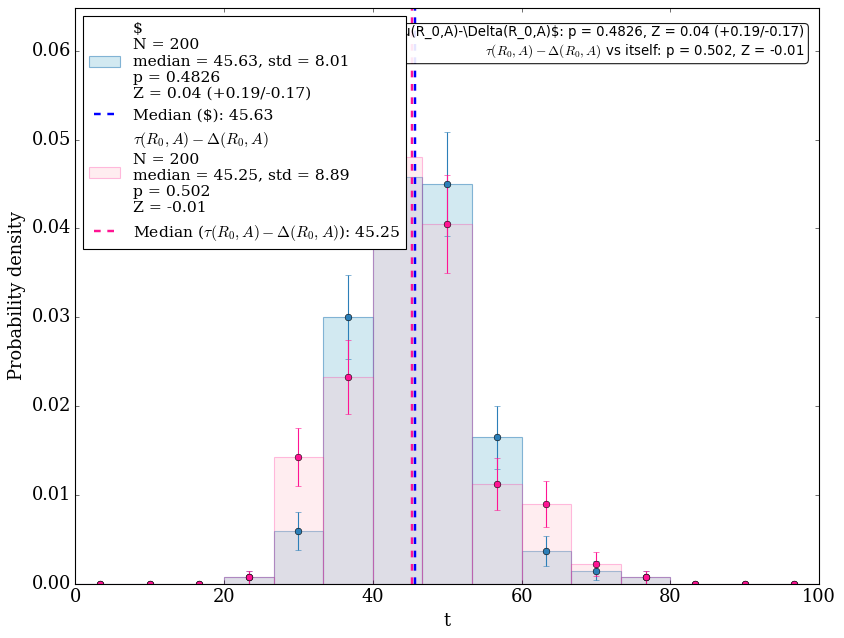

WC: .96
WC: .96


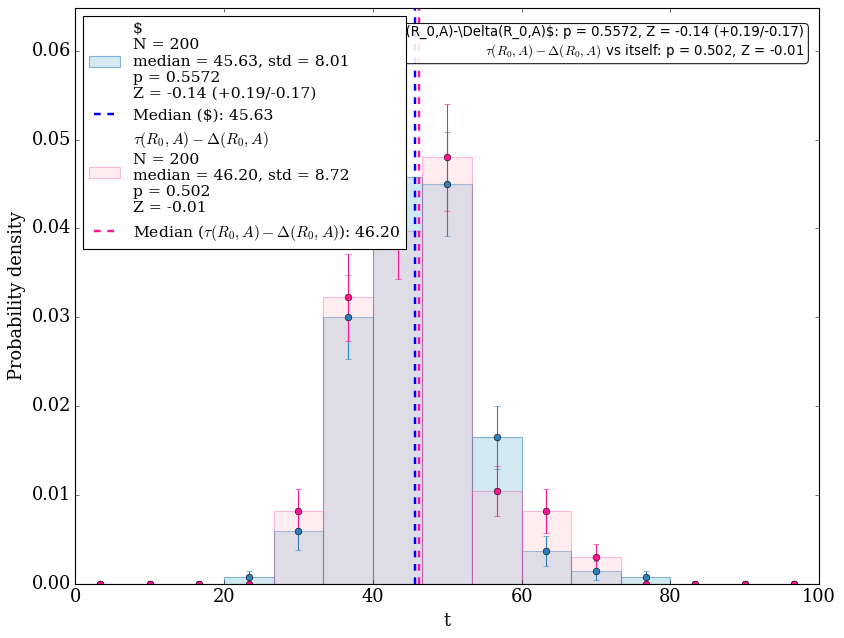

In [18]:
# return_list,nparams = plots(["/n/holystore01/LABS/iaifi_lab/Users/tshelley2002/Uncertainty_Project/NPLM_tests/Test7/D/Nref52000_Nbkg10000_Nsig100/SHAPE1_nuscale0.05_nuN0__epochsTau50000_epochsDelta1000_arc4_4_4_1_wclip1.97/",
#        "/n/holystore01/LABS/iaifi_lab/Users/tshelley2002/Uncertainty_Project/NPLM_tests/Test7/R0/Nref52000_Nbkg10000_Nsig100/SHAPE1_nuN0__epochsTau50000_epochsDelta1000_arc4_4_4_1_wclip1.97/"])


return_list,nparams  = plots(["/n/holystore01/LABS/iaifi_lab/Users/tshelley2002/Uncertainty_Project/NPLM_tests/Test9/R0/Nref52000_Nbkg10000/SHAPE1_nuN0__epochsTau50000_epochsDelta1000_arc4_4_4_1_wclip1.96/",
                     "/n/holystore01/LABS/iaifi_lab/Users/tshelley2002/Uncertainty_Project/NPLM_tests/Test9/D/Nref52000_Nbkg10000/SHAPE1_nuscale-0.025_nuN0__epochsTau50000_epochsDelta1000_arc4_4_4_1_wclip1.96/"])
     
taus_D,deltas_D, taus_R0,deltas_R0= return_list[0][0], return_list[0][1],return_list[1][0],return_list[1][1]

plot_2distribution1(
    (taus_D - deltas_D)[:],
    (taus_R0 - deltas_R0)[:],
    #df=nparams, 
    xmin=0, xmax=100, nbins=15,
    label1=r"$",
    label2=r"$\tau(R_0,A)-\Delta(R_0,A)$",)



return_list,nparams  = plots(["/n/holystore01/LABS/iaifi_lab/Users/tshelley2002/Uncertainty_Project/NPLM_tests/Test9/R0/Nref52000_Nbkg10000/SHAPE1_nuN0__epochsTau50000_epochsDelta1000_arc4_4_4_1_wclip1.96/",
                     "/n/holystore01/LABS/iaifi_lab/Users/tshelley2002/Uncertainty_Project/NPLM_tests/Test9/D/Nref52000_Nbkg10000/SHAPE1_nuscale0.025_nuN0__epochsTau50000_epochsDelta1000_arc4_4_4_1_wclip1.96/"])
     
taus_D,deltas_D, taus_R0,deltas_R0= return_list[0][0], return_list[0][1],return_list[1][0],return_list[1][1]

plot_2distribution1(
    (taus_D - deltas_D)[:],
    (taus_R0 - deltas_R0)[:],
    #df=nparams, 
    xmin=0, xmax=100, nbins=15,
    label1=r"$",
    label2=r"$\tau(R_0,A)-\Delta(R_0,A)$",)

WC: .96
WC: .96


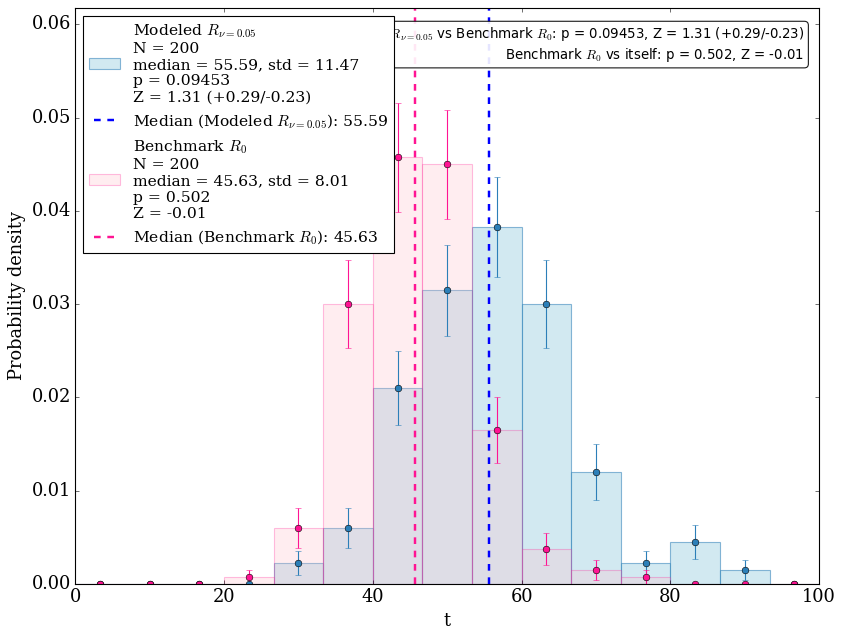

WC: .96
WC: .96


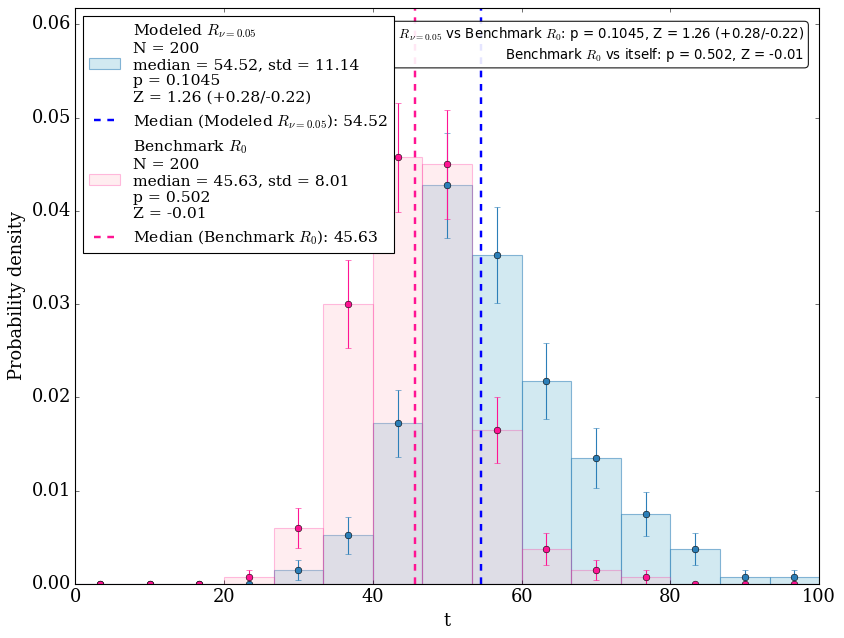

WC: .96
WC: .96


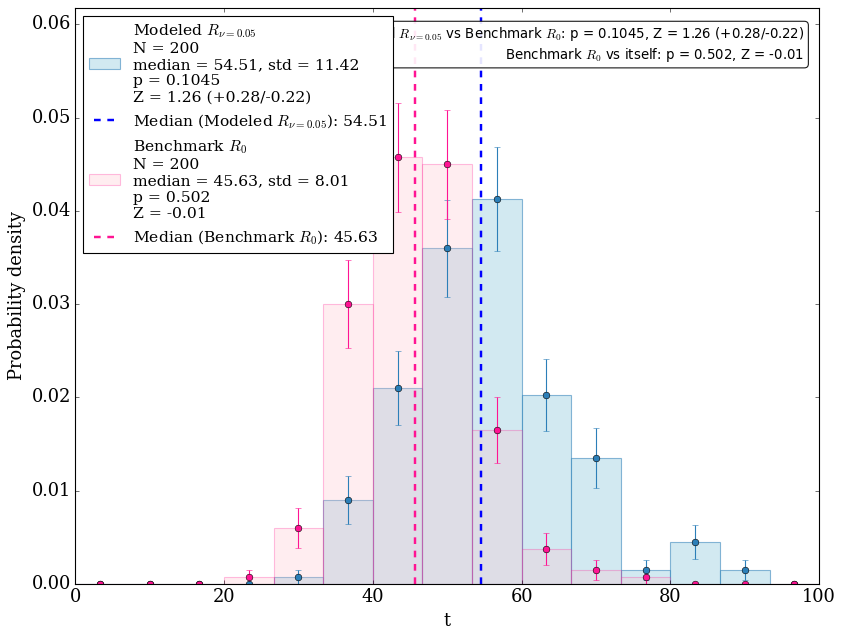

WC: .96
WC: .96


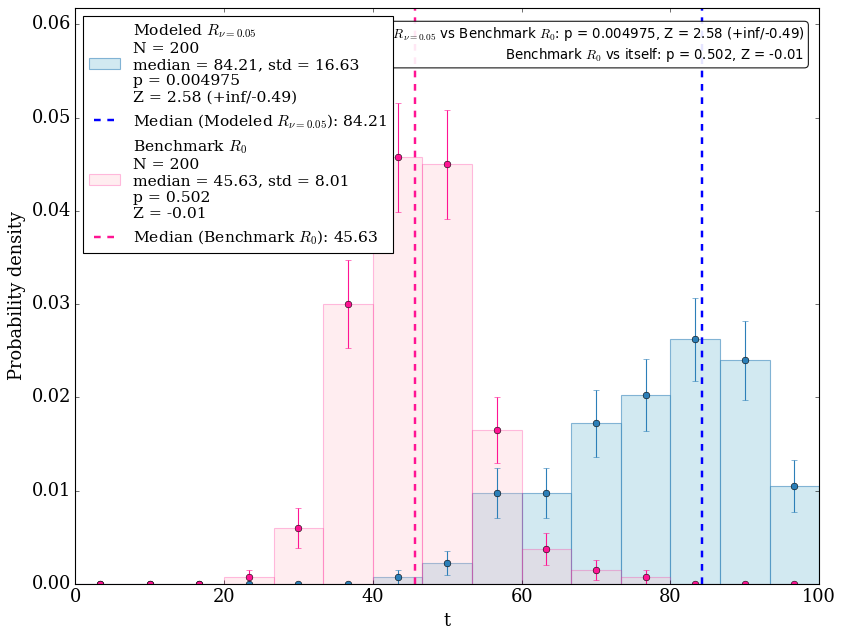

WC: .96
WC: .96


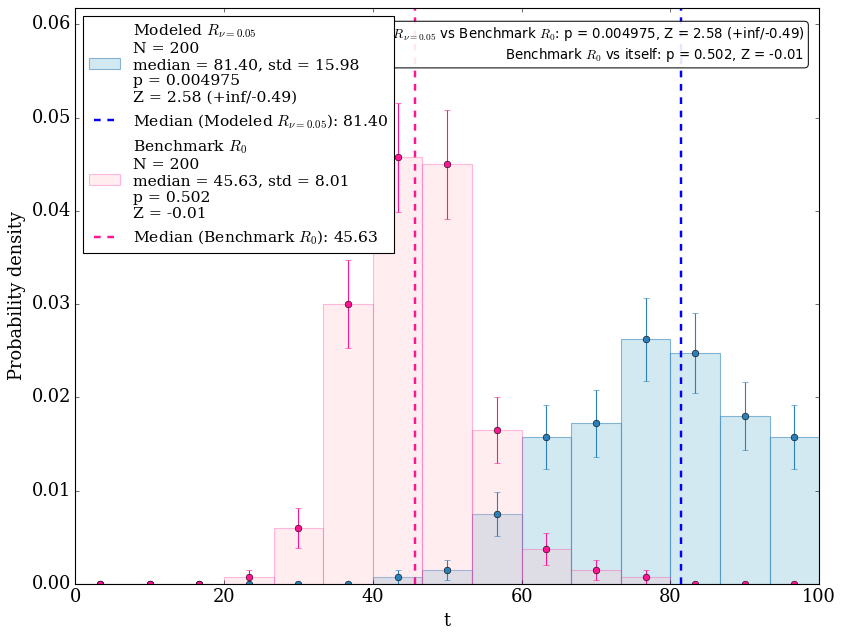

WC: .96
WC: .96


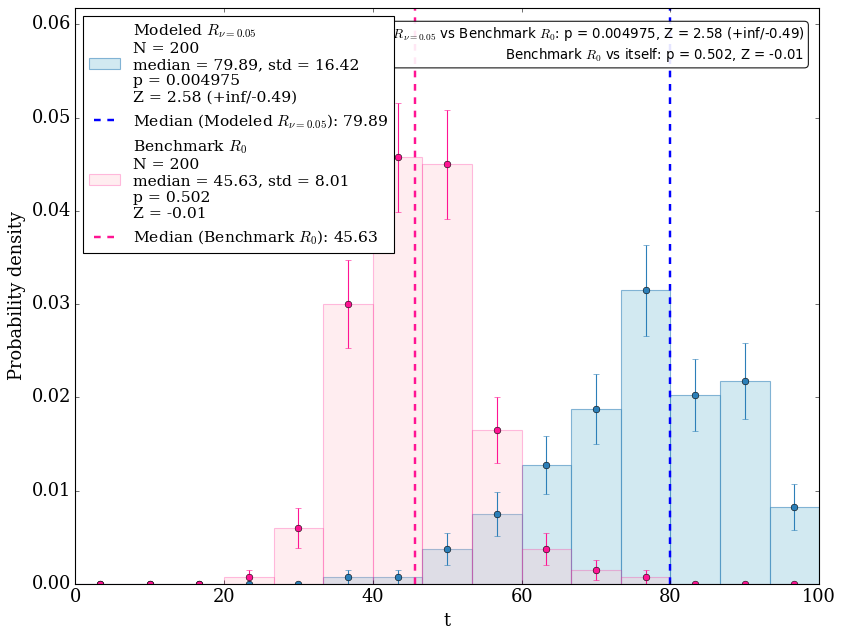

WC: .96
WC: .96


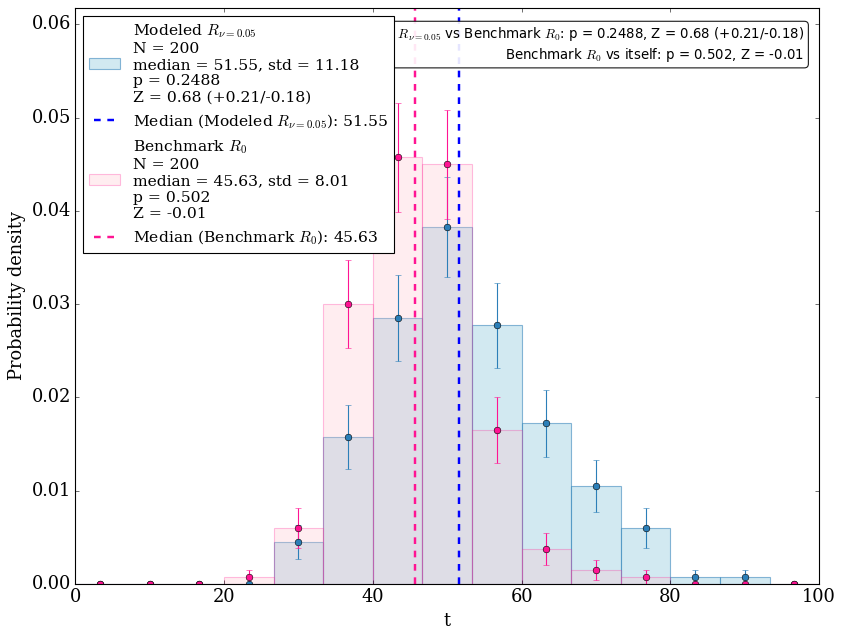

WC: .96
WC: .96


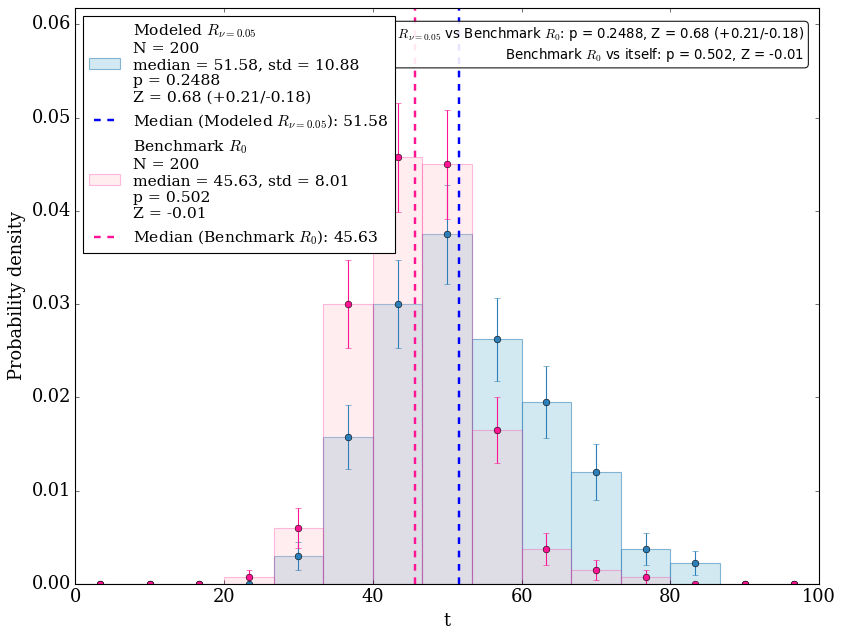

WC: .96
WC: .96


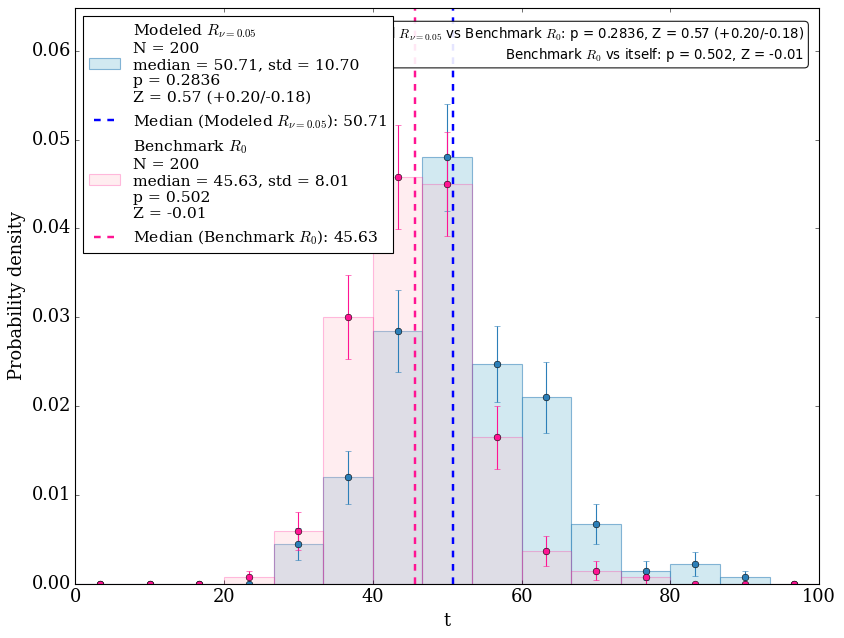

WC: .96
WC: .96


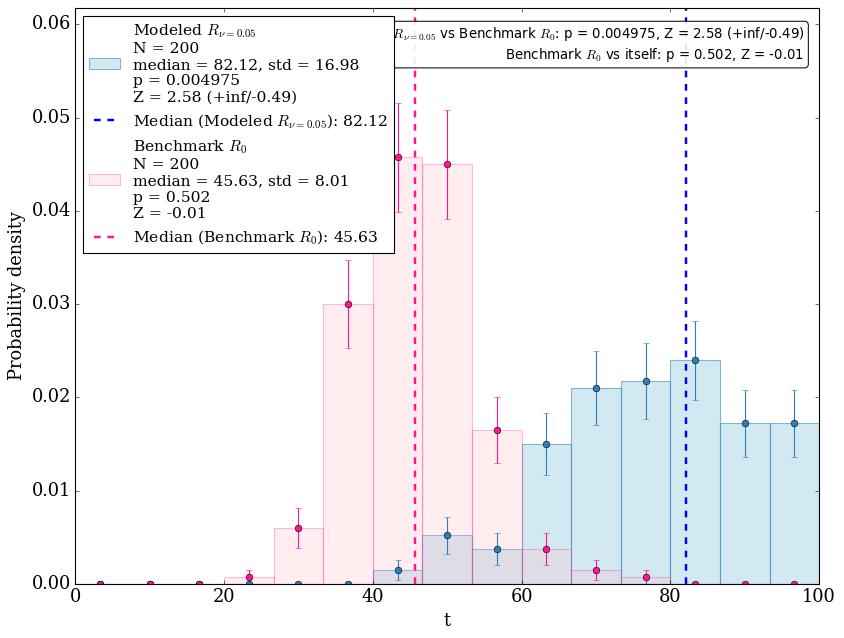

WC: .96
WC: .96


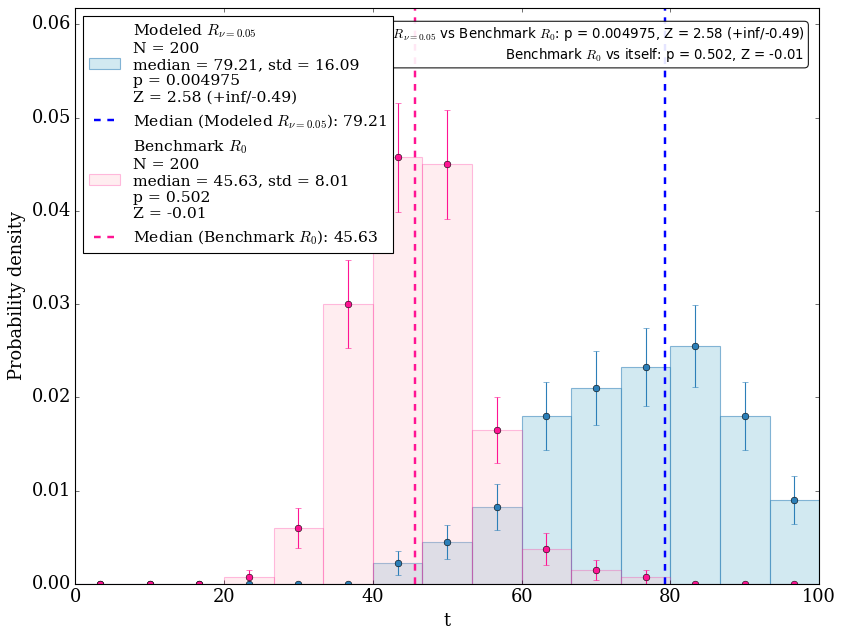

WC: .96
WC: .96


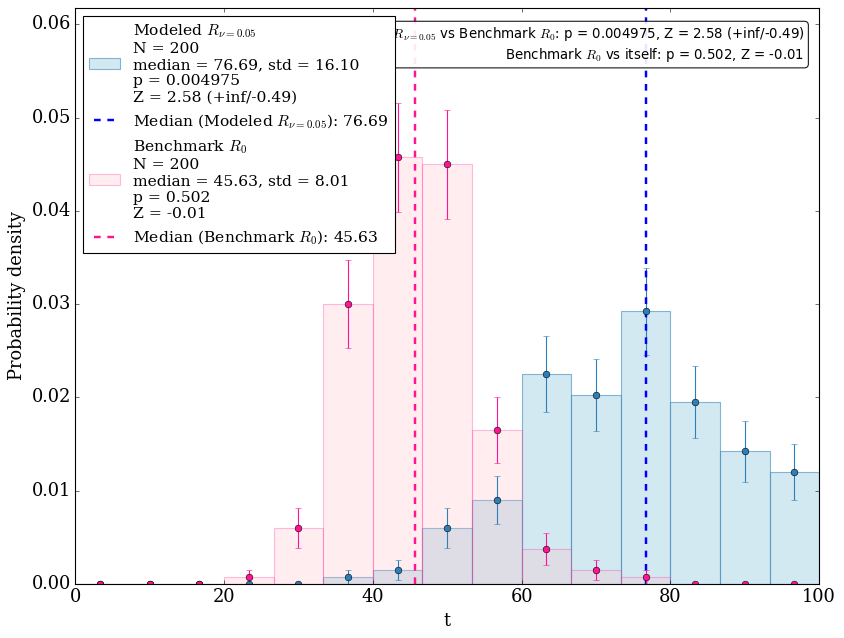

In [20]:
base_dir = "/n/holystore01/LABS/iaifi_lab/Users/tshelley2002/Uncertainty_Project/NPLM_tests/Test9/"
r0_dir = base_dir + "R0/Nref52000_Nbkg10000/SHAPE1_nuN0__epochsTau50000_epochsDelta1000_arc4_4_4_1_wclip1.96/"
paths = [(r0_dir, base_dir + "R0/leptoquark/Nref52000_Nbkg10000_Nsig100/SHAPE1_nuN0__epochsTau50000_epochsDelta1000_arc4_4_4_1_wclip1.96/"),
         (r0_dir, base_dir + "D/leptoquark/Nref52000_Nbkg10000_Nsig100/SHAPE1_nuscale0.025_nuN0__epochsTau50000_epochsDelta1000_arc4_4_4_1_wclip1.96/"),
         (r0_dir, base_dir + "D/leptoquark/Nref52000_Nbkg10000_Nsig100/SHAPE1_nuscale-0.025_nuN0__epochsTau50000_epochsDelta1000_arc4_4_4_1_wclip1.96/"),
         (r0_dir, base_dir + "R0/ato4l/Nref52000_Nbkg10000_Nsig100/SHAPE1_nuN0__epochsTau50000_epochsDelta1000_arc4_4_4_1_wclip1.96/"),
         (r0_dir, base_dir + "D/ato4l/Nref52000_Nbkg10000_Nsig100/SHAPE1_nuscale0.025_nuN0__epochsTau50000_epochsDelta1000_arc4_4_4_1_wclip1.96/"),
         (r0_dir, base_dir + "D/ato4l/Nref52000_Nbkg10000_Nsig100/SHAPE1_nuscale-0.025_nuN0__epochsTau50000_epochsDelta1000_arc4_4_4_1_wclip1.96/"),
         (r0_dir, base_dir + "R0/hToTauTau/Nref52000_Nbkg10000_Nsig100/SHAPE1_nuN0__epochsTau50000_epochsDelta1000_arc4_4_4_1_wclip1.96/"),
         (r0_dir, base_dir + "D/hToTauTau/Nref52000_Nbkg10000_Nsig100/SHAPE1_nuscale0.025_nuN0__epochsTau50000_epochsDelta1000_arc4_4_4_1_wclip1.96/"),
         (r0_dir, base_dir + "D/hToTauTau/Nref52000_Nbkg10000_Nsig100/SHAPE1_nuscale-0.025_nuN0__epochsTau50000_epochsDelta1000_arc4_4_4_1_wclip1.96/"),
         (r0_dir, base_dir + "R0/hChToTauNu/Nref52000_Nbkg10000_Nsig100/SHAPE1_nuN0__epochsTau50000_epochsDelta1000_arc4_4_4_1_wclip1.96/"),
         (r0_dir, base_dir + "D/hChToTauNu/Nref52000_Nbkg10000_Nsig100/SHAPE1_nuscale0.025_nuN0__epochsTau50000_epochsDelta1000_arc4_4_4_1_wclip1.96/"),
         (r0_dir, base_dir + "D/hChToTauNu/Nref52000_Nbkg10000_Nsig100/SHAPE1_nuscale-0.025_nuN0__epochsTau50000_epochsDelta1000_arc4_4_4_1_wclip1.96/")]

for i in range(len(paths)):
    
    return_list,nparams  = plots([paths[i][0],paths[i][1]])
    taus_R0,deltas_R0, taus_D,deltas_D = return_list[0][0], return_list[0][1],return_list[1][0],return_list[1][1]
    
    plot_2distribution1(
        (taus_D - deltas_D)[:],
        (taus_R0 - deltas_R0)[:],
        #df=nparams, 
        xmin=0, xmax=100, nbins=15,)
        #label1=r"$",
        #label2=r"$\tau(R_0,A)-\Delta(R_0,A)$",)


WC: .96


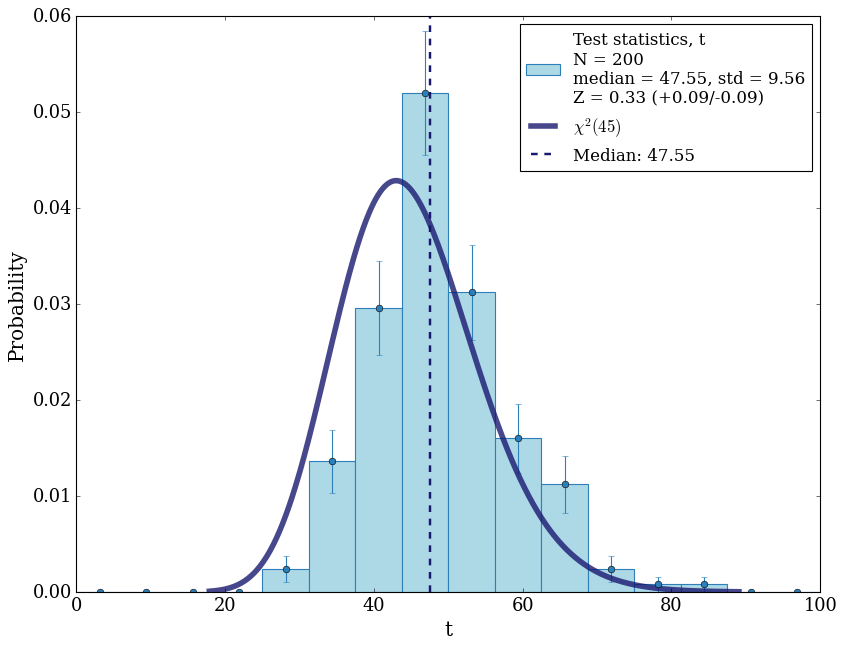

WC: .96


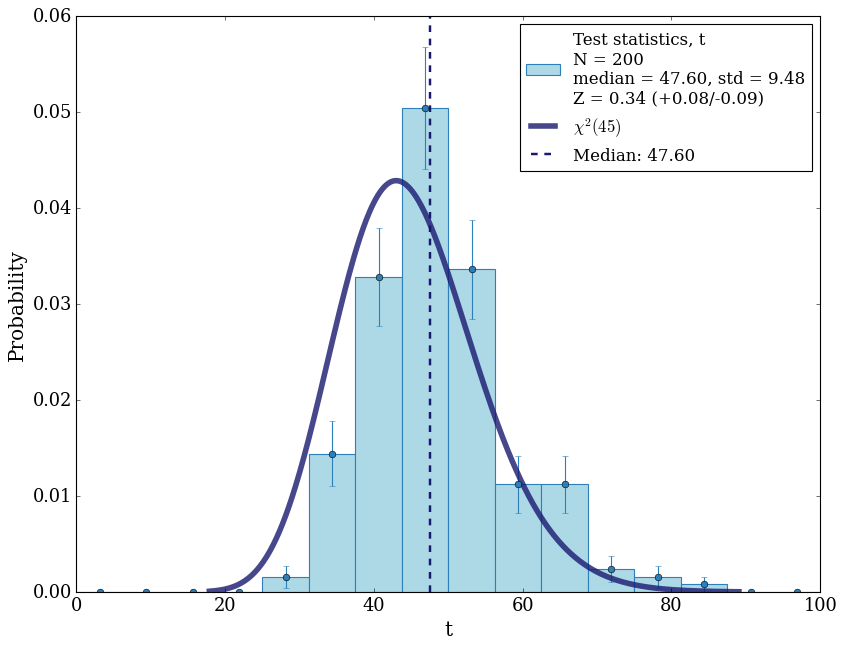

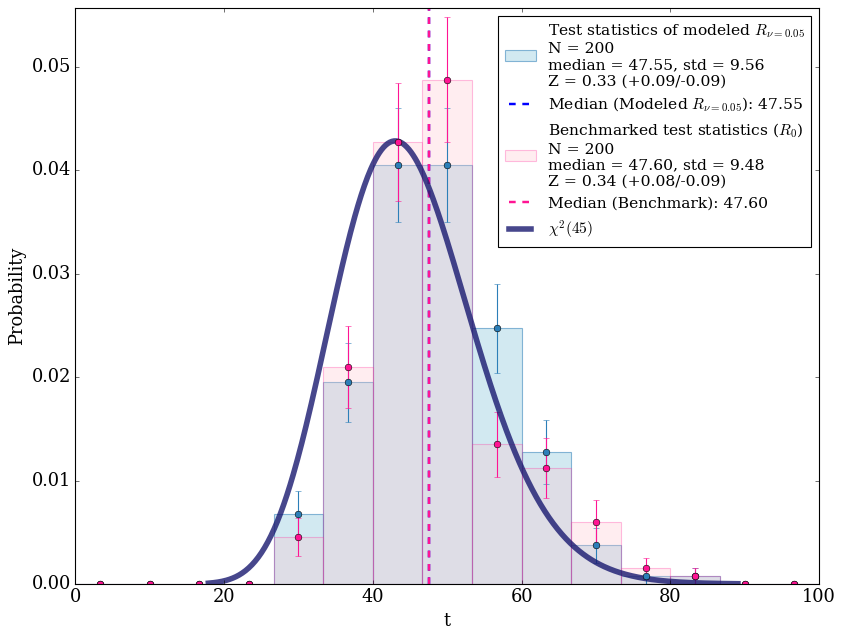

WC: .96


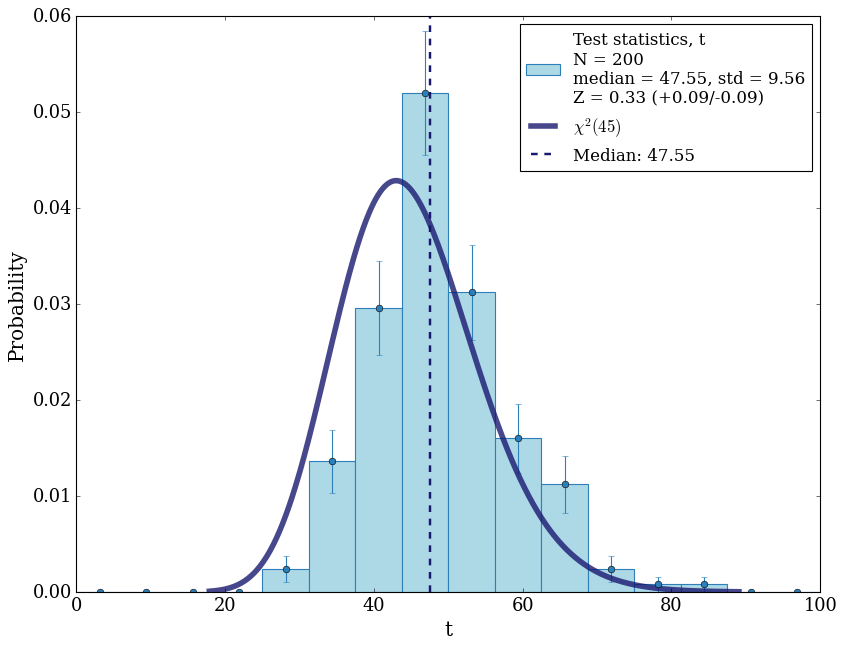

WC: .96


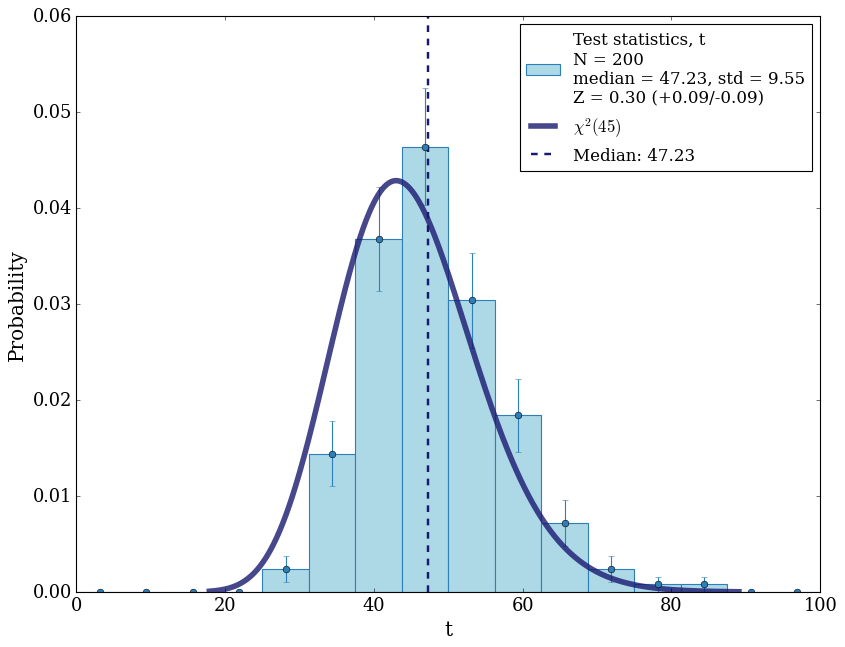

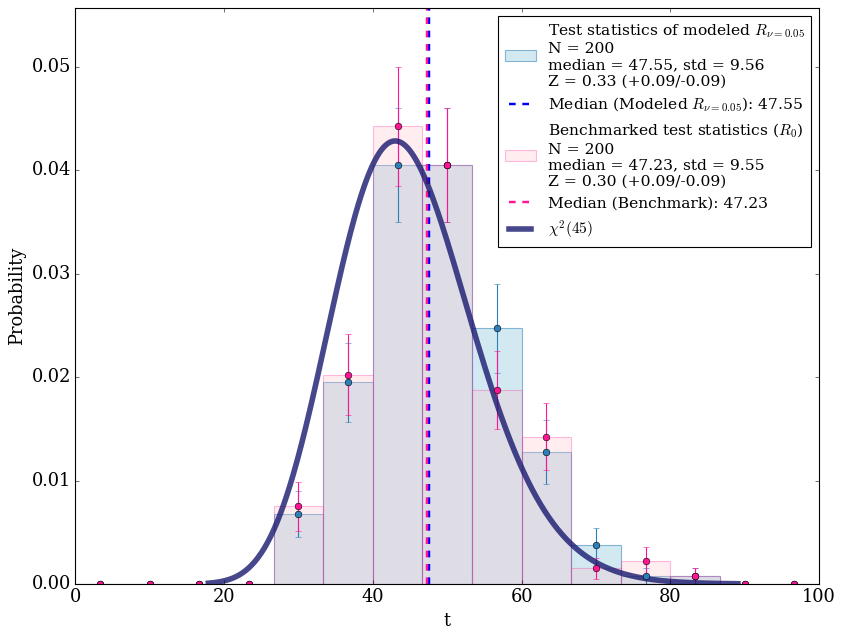

In [34]:
return_list,nparams  = plots(["/n/holystore01/LABS/iaifi_lab/Users/tshelley2002/Uncertainty_Project/NPLM_tests/Test9/R0/Nref52000_Nbkg10000/SHAPE1_nuN0__epochsTau50000_epochsDelta1000_arc4_4_4_1_wclip1.96/",
                     "/n/holystore01/LABS/iaifi_lab/Users/tshelley2002/Uncertainty_Project/NPLM_tests/Test9/R0/leptoquark/Nref52000_Nbkg10000_Nsig100/SHAPE1_nuN0__epochsTau50000_epochsDelta1000_arc4_4_4_1_wclip1.96/"])
   
return_list,nparams  = plots(["/n/holystore01/LABS/iaifi_lab/Users/tshelley2002/Uncertainty_Project/NPLM_tests/Test9/R0/Nref52000_Nbkg10000/SHAPE1_nuN0__epochsTau50000_epochsDelta1000_arc4_4_4_1_wclip1.96/",
                     "/n/holystore01/LABS/iaifi_lab/Users/tshelley2002/Uncertainty_Project/NPLM_tests/Test9/D/leptoquark/Nref52000_Nbkg10000_Nsig100/SHAPE1_nuscale0.025_nuN0__epochsTau50000_epochsDelta1000_arc4_4_4_1_wclip1.96/"])
     
taus_D,deltas_D, taus_R0,deltas_R0= return_list[0][0], return_list[0][1],return_list[1][0],return_list[1][1]

plot_2distribution1(
    (taus_D - deltas_D)[:],
    (taus_R0 - deltas_R0)[:],
    df=nparams, 
    xmin=0, xmax=100, nbins=15,
    label1=r"$",
    label2=r"$\tau(R_0,A)-\Delta(R_0,A)$",)


taus_D,deltas_D, taus_R0,deltas_R0= return_list[0][0], return_list[0][1],return_list[1][0],return_list[1][1]

plot_2distribution1(
    (taus_D - deltas_D)[:],
    (taus_R0 - deltas_R0)[:],
    df=nparams, 
    xmin=0, xmax=100, nbins=15,
    label1=r"$",
    label2=r"$\tau(R_0,A)-\Delta(R_0,A)$",)